In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


<h2>Comparing different model in volatile situation<h2>

In [2]:
# import dataset and normalise them
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/final_project/final_dataset.csv')

# drop the first column as it is just the index of each row
data = data.drop(columns=['Unnamed: 0'])

scaler = MinMaxScaler(feature_range=(-1, 1))
data[['Close', 'Open', 'High', 'Low', 'Volume']] = scaler.fit_transform(data[['Close', 'Open', 'High', 'Low', 'Volume']])

data.head()

,Close,Open,Low,High,Volume,sentiment_rolling_7,sentiment_rolling_14,sentiment_rolling_30,sentiment_score
0,0.088426,0.119532,0.123737,0.076550,-0.732980,-0.05598,-0.056158,-0.056577,0.191575
1,0.042536,0.106963,0.094518,0.054964,-0.780083,-0.05598,-0.056158,-0.056577,0.142081
2,0.016498,0.024403,0.077856,0.064696,-0.690539,-0.05598,-0.056158,-0.056577,-0.011418
3,0.074206,0.051613,0.079074,0.063811,-0.729364,-0.05598,-0.056158,-0.056577,-0.115670
4,0.045549,0.099115,0.119445,0.083751,-0.823126,-0.05598,-0.056158,-0.056577,-0.126334


In [3]:
import numpy as np

# function to create sequences of data
def create_sequences(data, sequnece_length):
  sequences = []
  targets = []
  for i in range(len(data) - sequnece_length):
    sequences.append(data[i:i+sequnece_length])
    targets.append(data[i+sequnece_length - 1, 0]) # the target is the next day close price
  return np.array(sequences), np.array(targets)

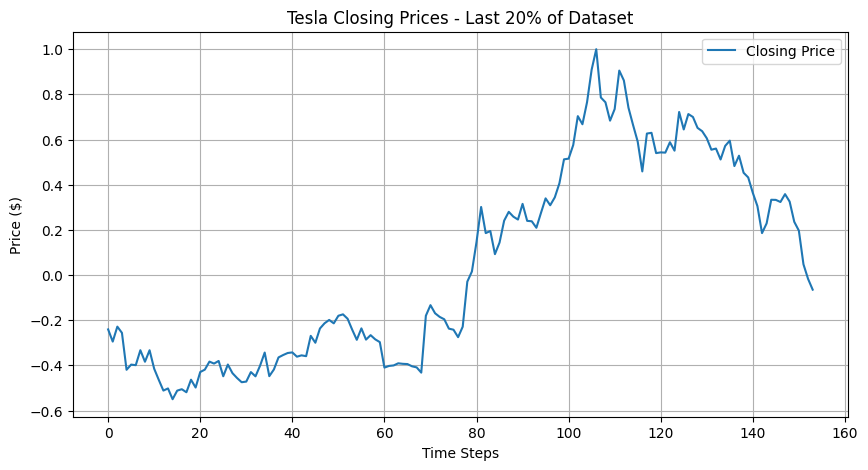

In [4]:
import matplotlib.pyplot as plt

# split the dataset as before to select the volatile time period
# select the last 20% of dataset (which is unseen to the models, it was the testing dataset in previous sections)
test_size = int(len(data) * 0.2)
data = data.iloc[-test_size:]

# plot the closing price to find the most volatile period
plt.figure(figsize=(10, 5))
plt.plot(data['Close'].values, label='Closing Price')
plt.title('Tesla Closing Prices - Last 20% of Dataset')
plt.xlabel('Time Steps')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()

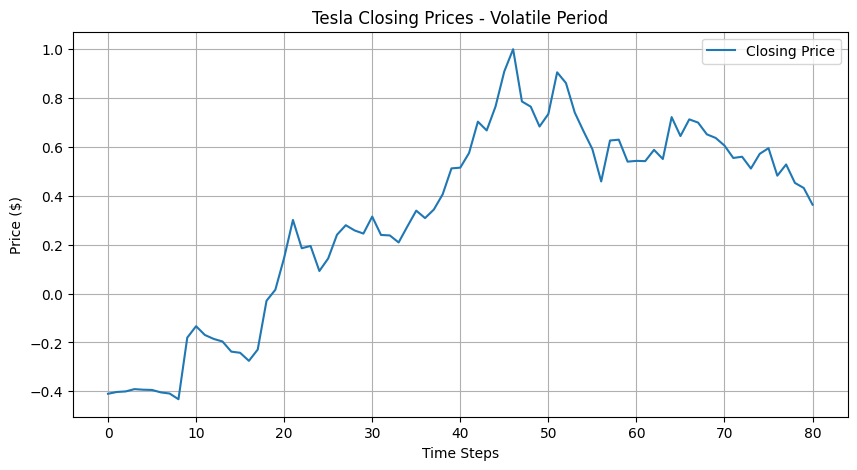

In [5]:
# As we can see, from around day 90 to day 140 is a good choice, as it contains sharp declines and increases.
# In code, I put 60 as a starting point for slicing because I need to create sequences for the day 90th, so I need to start from
# day 60, the sequence length is 30
data_volatile = data.iloc[60:141]

plt.figure(figsize=(10, 5))
plt.plot(data_volatile['Close'].values, label='Closing Price')
plt.title('Tesla Closing Prices - Volatile Period')
plt.xlabel('Time Steps')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
data_volatile.head()

,Close,Open,Low,High,Volume,sentiment_rolling_7,sentiment_rolling_14,sentiment_rolling_30,sentiment_score
676,-0.409834,-0.371789,-0.367051,-0.407681,-0.217132,-0.161703,-0.116001,-0.096344,-0.070745
677,-0.402518,-0.371789,-0.370649,-0.415271,-0.635337,-0.215866,-0.167907,-0.118359,-0.691677
678,-0.400312,-0.372432,-0.351645,-0.402797,-0.808322,-0.173369,-0.163655,-0.110146,-0.140572
679,-0.390844,-0.364977,-0.341468,-0.410441,-0.907467,-0.169755,-0.171591,-0.098007,-0.246867
680,-0.393211,-0.363958,-0.347259,-0.414369,-0.898864,-0.133955,-0.137788,-0.094710,0.174380


In [7]:
# create a dataset without sentiment score
data_volatile_no_sentiment = data_volatile[['Close', 'Open', 'Low', 'High', 'Volume']]

In [8]:
# I found that in the grid search, all the models work better with sequence length of 30
# except the LSTM model without sentiment scores, which worked better with 60, so I created 2 different X and y

# create sequences
X_sentiment, y_sentiment = create_sequences(data_volatile.values, 30)
X_rnn_financial, y_rnn_financial = create_sequences(data_volatile_no_sentiment.values, 30)
X_lstm_financial, y_lstm_financial = create_sequences(data_volatile_no_sentiment.values, 30)

# convert them to tesnor
import torch
X_sentiment = torch.tensor(X_sentiment, dtype=torch.float32)
y_sentiment = torch.tensor(y_sentiment, dtype=torch.float32)
X_rnn_financial = torch.tensor(X_rnn_financial, dtype=torch.float32)
y_rnn_financial = torch.tensor(y_rnn_financial, dtype=torch.float32)
X_lstm_financial = torch.tensor(X_lstm_financial, dtype=torch.float32)
y_lstm_financial = torch.tensor(y_lstm_financial, dtype=torch.float32)

# define dataloaders (LSTM and RNN with sentiment scores performed better with different batch sizes)
from torch.utils.data import TensorDataset, DataLoader
sentiment_dataset = TensorDataset(X_sentiment, y_sentiment)
sentiment_rnn_loader = DataLoader(sentiment_dataset, batch_size=32, shuffle=False)
sentiment_lstm_loader = DataLoader(sentiment_dataset, batch_size=64, shuffle=False)
financial_rnn_loader = DataLoader(TensorDataset(X_rnn_financial, y_rnn_financial), batch_size=64, shuffle=False)
financial_lstm_loader = DataLoader(TensorDataset(X_lstm_financial, y_lstm_financial), batch_size=32, shuffle=False)

<h3>RNN with sentiment scores<h3>

best model evaluation:
MSE: 22.8474
RMSE: 4.7799
MAE: 3.6622
R² Score: 0.9800


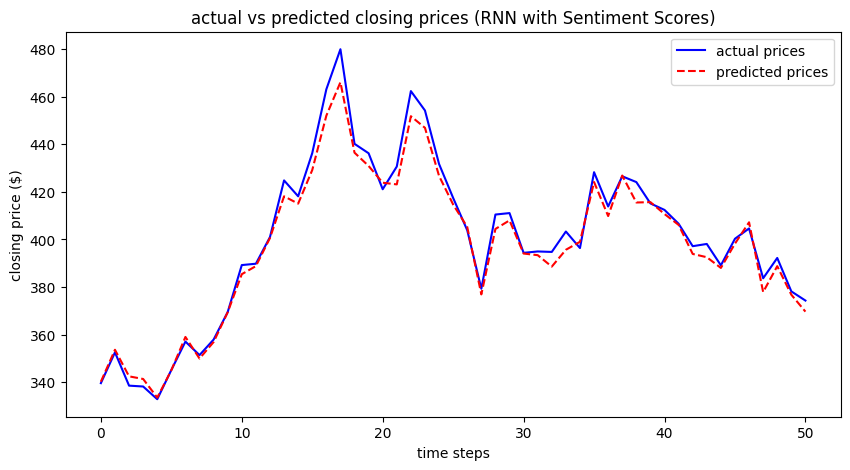

In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch.nn as nn

# load the RNN model with sentiment scores and evaluate it
class RNN_model(nn.Module):
  def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
    super(RNN_model, self).__init__()
    self.hidden_dim = hidden_dim
    self.num_layers = num_layers
    self.rnn = nn.RNN(input_dim, hidden_dim, num_layers, batch_first=True)
    self.fc = nn.Linear(hidden_dim, output_dim)

  def forward(self, x):
    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim)
    out, _ = self.rnn(x, h0)
    return self.fc(out[:, -1, :])

# initialise the model with best hyperparameters
rnn_sentiment = RNN_model(input_dim=9, hidden_dim=128, num_layers=3, output_dim=1)
rnn_sentiment.load_state_dict(torch.load('/content/drive/MyDrive/Colab Notebooks/final_project/rnn_model.pth'))

rnn_sentiment.eval()
y_true_lst = []
y_hat_lst = []
with torch.no_grad():
  for X_batch, y_batch in sentiment_rnn_loader:
    pred_batch = rnn_sentiment(X_batch).numpy()
    y_hat_lst.append(pred_batch)
    y_true_lst.append(y_batch.numpy())

# convert the lists to arrays
y_true = np.concatenate(y_true_lst, axis=0).squeeze()
y_hat = np.concatenate(y_hat_lst, axis=0).squeeze()

# the prediction should be converted into its original scale before noramlisation
# to see results in the real world prices
y_true_org = scaler.inverse_transform(np.column_stack((y_true, np.zeros((y_true.shape[0], 4)))))[:, 0]
y_hat_org = scaler.inverse_transform(np.column_stack((y_hat, np.zeros((y_hat.shape[0], 4)))))[:, 0]

mse_original = mean_squared_error(y_true_org, y_hat_org)
rmse_original = np.sqrt(mse_original)
mae_original = mean_absolute_error(y_true_org, y_hat_org)
r2_original = r2_score(y_true_org, y_hat_org)

print("best model evaluation:")
print(f"MSE: {mse_original:.4f}")
print(f"RMSE: {rmse_original:.4f}")
print(f"MAE: {mae_original:.4f}")
print(f"R² Score: {r2_original:.4f}")

# plot actual prices vs predicted prices
plt.figure(figsize=(10,5))
plt.plot(y_true_org, label="actual prices", color='blue')
plt.plot(y_hat_org, label="predicted prices", color='red', linestyle='dashed')
plt.legend()
plt.title("actual vs predicted closing prices (RNN with Sentiment Scores)")
plt.xlabel("time steps")
plt.ylabel("closing price ($)")
plt.show()

<h2>RNN without Sentiment Scores<h2>

best model evaluation:
MSE: 122.5830
RMSE: 11.0717
MAE: 8.9487
R² Score: 0.8926


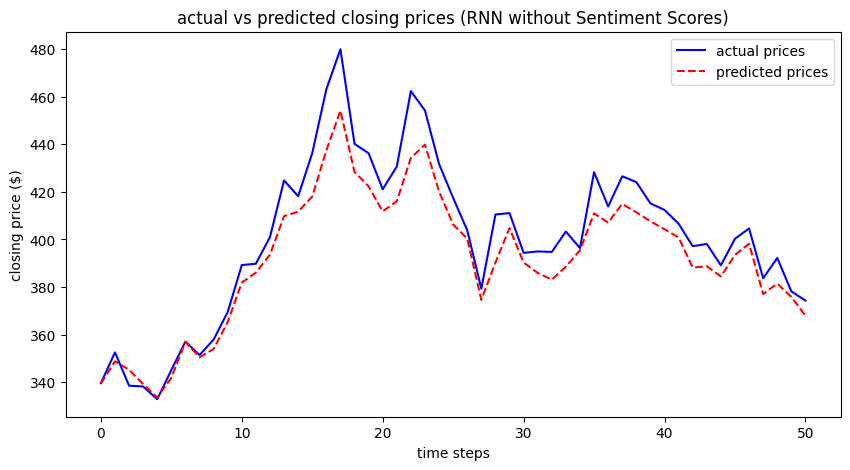

In [10]:
# load and evaluate RNN model without sentiment scores
rnn_financial = RNN_model(input_dim=5, hidden_dim=64, num_layers=3, output_dim=1)
rnn_financial.load_state_dict(torch.load('/content/drive/MyDrive/Colab Notebooks/final_project/rnn_model_with_financial_metrics.pth'))

rnn_financial.eval()
y_true_lst = []
y_hat_lst = []
with torch.no_grad():
  for X_batch, y_batch in financial_rnn_loader:
    pred_batch = rnn_financial(X_batch).numpy()
    y_hat_lst.append(pred_batch)
    y_true_lst.append(y_batch.numpy())

# convert the lists to arrays
y_true = np.concatenate(y_true_lst, axis=0).squeeze()
y_hat = np.concatenate(y_hat_lst, axis=0).squeeze()

# the prediction should be converted into its original scale before noramlisation
# to see results in the real world prices
y_true_org = scaler.inverse_transform(np.column_stack((y_true, np.zeros((y_true.shape[0], 4)))))[:, 0]
y_hat_org = scaler.inverse_transform(np.column_stack((y_hat, np.zeros((y_hat.shape[0], 4)))))[:, 0]

mse_original = mean_squared_error(y_true_org, y_hat_org)
rmse_original = np.sqrt(mse_original)
mae_original = mean_absolute_error(y_true_org, y_hat_org)
r2_original = r2_score(y_true_org, y_hat_org)

print("best model evaluation:")
print(f"MSE: {mse_original:.4f}")
print(f"RMSE: {rmse_original:.4f}")
print(f"MAE: {mae_original:.4f}")
print(f"R² Score: {r2_original:.4f}")

# plot actual prices vs predicted prices
plt.figure(figsize=(10,5))
plt.plot(y_true_org, label="actual prices", color='blue')
plt.plot(y_hat_org, label="predicted prices", color='red', linestyle='dashed')
plt.legend()
plt.title("actual vs predicted closing prices (RNN without Sentiment Scores)")
plt.xlabel("time steps")
plt.ylabel("closing price ($)")
plt.show()

<h2>LSTM with Sentiment Scores<h2>

best model evaluation:
MSE: 16.4923
RMSE: 4.0611
MAE: 3.3242
R² Score: 0.9856


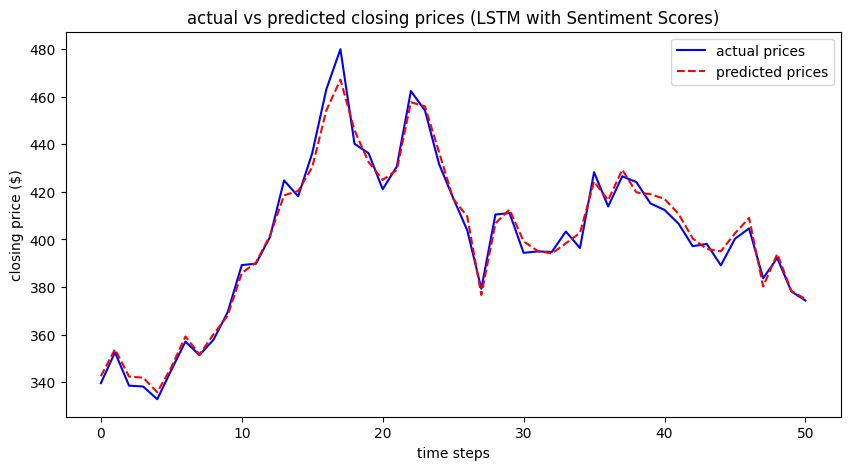

In [11]:
# load and evaluate LSTM model with sentiment scores
class LSTM_model(nn.Module):
  def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout=0.5):
    super(LSTM_model, self).__init__()
    self.hidden_dim = hidden_dim
    self.num_layers = num_layers
    self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                        dropout=dropout if num_layers > 1 else 0, batch_first=True)
    self.fc = nn.Linear(hidden_dim, output_dim)

  def forward(self, x):
    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim)
    c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim)
    out, _ = self.lstm(x, (h0, c0))
    return self.fc(out[:, -1, :])

lstm_sentiment = LSTM_model(input_dim=9, hidden_dim=128, num_layers=2, output_dim=1)
lstm_sentiment.load_state_dict(torch.load('/content/drive/MyDrive/Colab Notebooks/final_project/lstm_model.pth'))
lstm_sentiment.eval()
y_true_lst = []
y_hat_lst = []
with torch.no_grad():
  for X_batch, y_batch in sentiment_lstm_loader:
    pred_batch = lstm_sentiment(X_batch).numpy()
    y_hat_lst.append(pred_batch)
    y_true_lst.append(y_batch.numpy())

# convert the lists to arrays
y_true = np.concatenate(y_true_lst, axis=0).squeeze()
y_hat = np.concatenate(y_hat_lst, axis=0).squeeze()

# the prediction should be converted into its original scale before noramlisation
# to see results in the real world prices
y_true_org = scaler.inverse_transform(np.column_stack((y_true, np.zeros((y_true.shape[0], 4)))))[:, 0]
y_hat_org = scaler.inverse_transform(np.column_stack((y_hat, np.zeros((y_hat.shape[0], 4)))))[:, 0]

mse_original = mean_squared_error(y_true_org, y_hat_org)
rmse_original = np.sqrt(mse_original)
mae_original = mean_absolute_error(y_true_org, y_hat_org)
r2_original = r2_score(y_true_org, y_hat_org)

print("best model evaluation:")
print(f"MSE: {mse_original:.4f}")
print(f"RMSE: {rmse_original:.4f}")
print(f"MAE: {mae_original:.4f}")
print(f"R² Score: {r2_original:.4f}")

# plot actual prices vs predicted prices
plt.figure(figsize=(10,5))
plt.plot(y_true_org, label="actual prices", color='blue')
plt.plot(y_hat_org, label="predicted prices", color='red', linestyle='dashed')
plt.legend()
plt.title("actual vs predicted closing prices (LSTM with Sentiment Scores)")
plt.xlabel("time steps")
plt.ylabel("closing price ($)")
plt.show()

<h2>LSTM without Sentiment Scores<h2>

best model evaluation:
MSE: 97.3892
RMSE: 9.8686
MAE: 6.3717
R² Score: 0.9147


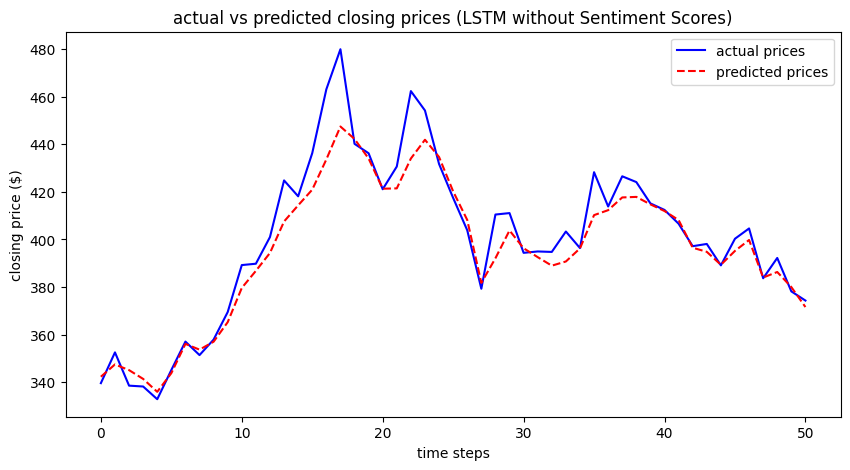

In [12]:
# load and evaluate LSTM model with just financial metrics
lstm_financial = LSTM_model(input_dim=5, hidden_dim=128, num_layers=3, output_dim=1)
lstm_financial.load_state_dict(torch.load('/content/drive/MyDrive/Colab Notebooks/final_project/lstm_model_with_financil_metrics.pth'))
lstm_financial.eval()
y_true_lst = []
y_hat_lst = []
with torch.no_grad():
  for X_batch, y_batch in financial_lstm_loader:
    pred_batch = lstm_financial(X_batch).numpy()
    y_hat_lst.append(pred_batch)
    y_true_lst.append(y_batch.numpy())

# convert the lists to arrays
y_true = np.concatenate(y_true_lst, axis=0).squeeze()
y_hat = np.concatenate(y_hat_lst, axis=0).squeeze()

# the prediction should be converted into its original scale before noramlisation
# to see results in the real world prices
y_true_org_2 = scaler.inverse_transform(np.column_stack((y_true, np.zeros((y_true.shape[0], 4)))))[:, 0]
y_hat_org_2 = scaler.inverse_transform(np.column_stack((y_hat, np.zeros((y_hat.shape[0], 4)))))[:, 0]

mse_original = mean_squared_error(y_true_org_2, y_hat_org_2)
rmse_original = np.sqrt(mse_original)
mae_original = mean_absolute_error(y_true_org_2, y_hat_org_2)
r2_original = r2_score(y_true_org_2, y_hat_org_2)

print("best model evaluation:")
print(f"MSE: {mse_original:.4f}")
print(f"RMSE: {rmse_original:.4f}")
print(f"MAE: {mae_original:.4f}")
print(f"R² Score: {r2_original:.4f}")

# plot actual prices vs predicted prices
plt.figure(figsize=(10,5))
plt.plot(y_true_org_2, label="actual prices", color='blue')
plt.plot(y_hat_org_2, label="predicted prices", color='red', linestyle='dashed')
plt.legend()
plt.title("actual vs predicted closing prices (LSTM without Sentiment Scores)")
plt.xlabel("time steps")
plt.ylabel("closing price ($)")
plt.show()

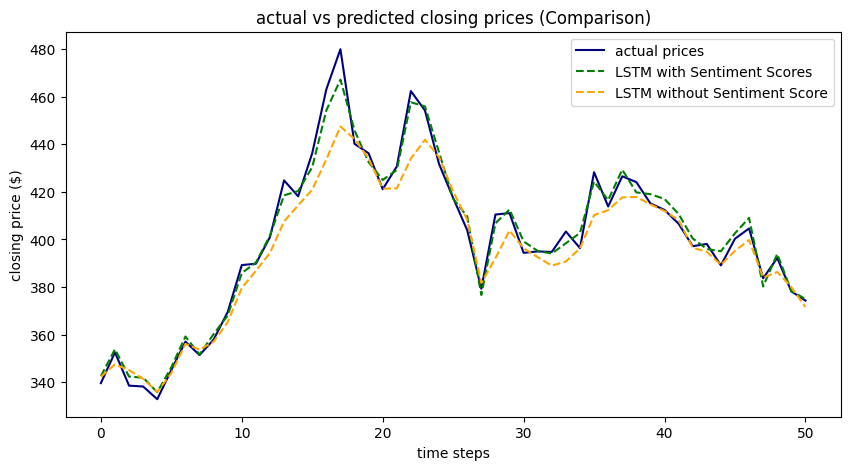

In [18]:
plt.figure(figsize=(10,5))
plt.plot(y_true_org, label="actual prices", color='navy')
plt.plot(y_hat_org, label="LSTM with Sentiment Scores", color='green', linestyle='dashed')
plt.plot(y_hat_org_2, label="LSTM without Sentiment Score", color='orange',linestyle='dashed')
plt.legend()
plt.title("actual vs predicted closing prices (Comparison)")
plt.xlabel("time steps")
plt.ylabel("closing price ($)")
plt.show()